<a href="https://colab.research.google.com/github/chalakafernando4/quantum-computing-tutorials/blob/main/12_Superdense_Coding/Superdense_Coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Data Compression: Superdense Coding

This notebook implements the Superdense Coding protocol. It demonstrates a fundamental quantum communication advantage: the ability to transmit two classical bits of information between two parties by transmitting only a single physical qubit, leveraging a pre-shared entangled state.

## Teleportation vs. Superdense Coding

* **Quantum Teleportation:** Transmits 1 *quantum* state by sending 2 *classical* bits.
* **Superdense Coding:** Transmits 2 *classical* bits by sending 1 *quantum* bit.

Both protocols rely on the exact same underlying resource: a shared Bell State (an entangled pair of qubits).

## The Protocol

Imagine Alice wants to send a 2-bit classical message (`00`, `01`, `10`, or `11`) to Bob.

1. **Entanglement Distribution:** A third party generates an entangled Bell pair. Alice is given Qubit A, and Bob is given Qubit B.
2. **Alice's Encoding:** Depending on the 2-bit message she wants to send, Alice applies a specific set of quantum gates (Pauli-X and/or Pauli-Z) to *her* qubit only.
* `00` $\rightarrow$ Apply Identity (Do nothing)
* `01` $\rightarrow$ Apply X gate
* `10` $\rightarrow$ Apply Z gate
* `11` $\rightarrow$ Apply Z and X gates


3. **Transmission:** Alice physically sends her single Qubit A to Bob.
4. **Bob's Decoding:** Bob now holds both entangled qubits. He applies a CNOT gate and a Hadamard gate to disentangle them, and measures both. Because of how Alice altered the shared wave function, Bob's measurement will reveal her exact 2-bit message with 100% certainty.

In the code below, we simulate this protocol. You can change Alice's message to any 2-bit combination and watch Bob decode it perfectly.

---


In [1]:
!pip install qiskit qiskit-aer matplotlib pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=b1b5d6eb22b0fa8d912cef1c46d6e0e834a5af6adc74b3de5a4b7ee708f7c348
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


Initializing Superdense Coding Protocol...
Alice wants to send the message: '10'

--- Transmission Results ---
Bob decoded the message: '01'


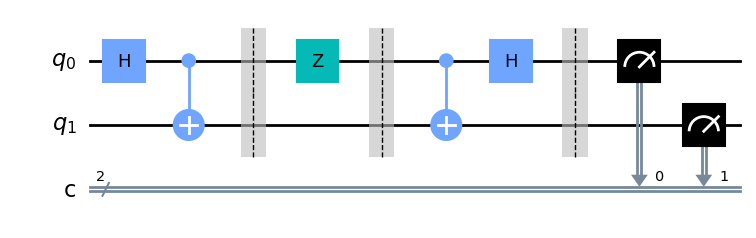

In [2]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def run_superdense_coding(message="11"):
    """
    Simulates the Superdense Coding protocol.
    Message must be '00', '01', '10', or '11'.
    """
    if message not in ["00", "01", "10", "11"]:
        raise ValueError("Message must be a 2-bit string.")

    print(f"Initializing Superdense Coding Protocol...")
    print(f"Alice wants to send the message: '{message}'\n")

    # We need 2 qubits (Alice's and Bob's) and 2 classical bits for decoding
    qc = QuantumCircuit(2, 2)

    # --- 1. Entanglement Distribution ---
    # Create a Bell pair (shared entanglement)
    qc.h(0)
    qc.cx(0, 1)
    qc.barrier()

    # --- 2. Alice's Encoding ---
    # Alice holds Qubit 0. She applies gates based on her message.
    # Qiskit reads strings right-to-left, so message[1] is the rightmost bit.
    if message[1] == '1':
        qc.x(0)
    if message[0] == '1':
        qc.z(0)
    qc.barrier()

    # --- 3. Transmission ---
    # Alice sends Qubit 0 to Bob. (In simulation, this is conceptual).

    # --- 4. Bob's Decoding ---
    # Bob applies the reverse Bell state circuit to decode the wave function
    qc.cx(0, 1)
    qc.h(0)
    qc.barrier()

    # Bob measures both qubits to reveal the 2 classical bits
    qc.measure([0, 1], [0, 1])

    # --- 5. Execution ---
    simulator = AerSimulator()
    job = simulator.run(qc, shots=1)
    result = job.result()
    counts = result.get_counts(qc)

    # Extract Bob's decoded message
    decoded_message = list(counts.keys())[0]

    print("--- Transmission Results ---")
    print(f"Bob decoded the message: '{decoded_message}'")

    if decoded_message == message:
        print("SUCCESS! Bob received the correct 2-bit message by receiving only 1 physical qubit.")

    # Draw the circuit schematic
    display(qc.draw('mpl', style='clifford'))

# You can change this message to "00", "01", "10", or "11"
run_superdense_coding("10")